# Hola Kevin! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class="alert alert-block alert-success">
<b>Comentario de Reviewer</b> <a class="tocSkip"></a>
    
Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario de Reviewer</b> <a class="tocSkip"></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de Reviewer</b> <a class="tocSkip"></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta estudiante.</b> <a class="tocSkip"></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión 1 <a class="tocSkip"></a>

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Buen trabajo Kevin, veo que has completado todo le notebook y está casi todo correcto. Solo hay un detalle en el cálculo de la duración de las llamadas, revisa los comentarios que te dejé al respecto. Con eso se corrigen las llamadas y el ingreso.
    
Saludos!    

</div>

## Resumen de la revisión 2 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Bien hecho Kevin, has completado correctamente todo lo necesario del notebook. No tengo comentarios de corrección adicionales, está aprobado.

Saludos!

</div>

----

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [118]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

## Cargar datos

In [119]:
# Carga los archivos de datos en diferentes DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [120]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()

#En esta ocasión la funcion DESCRIBE no nos brinda información relevante por lo que será eliminado
#plans.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [121]:
# Imprime una muestra de los datos para las tarifas
#Solo existen 2 registros dentro de este DF
plans.sample(2)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
1,1000,30720,3000,70,7,0.01,0.01,ultimate
0,50,15360,500,20,10,0.03,0.03,surf


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

    *Al solo tener 2 registros no existen ni elementos repetidos, ni nulos, ni con error de tipo. Yo solo modificaré el tipo de datos para las columnas de usd_monthly_pay y usd_per_gb de INT a FLOAT, esto ya que ambos son de naturaleza monetaria

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [122]:
#Validamos que no exista ningún problema durante la conversión ambas columnas
np.array_equal(plans['usd_monthly_pay'], plans['usd_monthly_pay'].astype('float'))
np.array_equal(plans['usd_per_gb'], plans['usd_per_gb'].astype('float'))

#convertimos las columnas de int a float
plans['usd_monthly_pay']= plans['usd_monthly_pay'].astype('float')
plans['usd_per_gb']= plans['usd_per_gb'].astype('float')
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(4), int64(3), object(1)
memory usage: 256.0+ bytes


## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [123]:
#No es necesario realizar más modificaciones

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien, correctas las modificaciones de este dataframe

</div>

## Usuarios/as

In [124]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

#La funcion DESCRIBE solo muestra calculas relevantes para la serie AGE
users['age'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


count    500.000000
mean      45.486000
std       16.972269
min       18.000000
25%       30.000000
50%       46.000000
75%       61.000000
max       75.000000
Name: age, dtype: float64

In [125]:
# Imprime una muestra de datos para usuarios
users.sample(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
348,1348,Carl,Rutledge,60,"Detroit-Warren-Dearborn, MI MSA",2018-10-05,surf,NaN
94,1094,Walter,Petersen,54,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-10-30,surf,2018-12-12
134,1134,Shannon,Nichols,71,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-09-03,surf,NaN
100,1100,Aaron,Rowe,65,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-13,surf,NaN
172,1172,Weldon,Robinson,72,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-30,surf,2018-11-29
89,1089,Malena,Kelley,70,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-09-03,surf,NaN
82,1082,Dominic,Witt,64,"Memphis, TN-MS-AR MSA",2018-04-15,surf,NaN
421,1421,Zane,Hobbs,26,"Phoenix-Mesa-Chandler, AZ MSA",2018-05-18,surf,NaN
423,1423,Malcom,Neal,61,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-10-16,surf,NaN
96,1096,Song,Cline,28,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-12-22,ultimate,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [126]:
#Buscamos registros duplicados
users[users.duplicated()]

#Buscamos en la única columna que cuenta con elementos nulos "churn_date"
users['churn_date'].isna().sum()

466

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [127]:
#Se mantendrán los usuarios activos (CHURN_DATE=NA) e inactivos para no alterar las posteriores operaciones y analisis

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

No te recomiendo separar los datos, no hay problema que hayan usuarios fugados y usuarios que no en el mismo dataframe.

</div>

## Llamadas

In [128]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()

#La funcion DESCRIBE solo muestra calculas relevantes para la serie DURATION
calls['duration'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


count    137735.000000
mean          6.745927
std           5.839241
min           0.000000
25%           1.290000
50%           5.980000
75%          10.690000
max          37.600000
Name: duration, dtype: float64

In [129]:
# Imprime una muestra de datos para las llamadas
calls.sample(10)

,id,user_id,call_date,duration
58271,1210_393,1210,2018-06-25,14.54
56742,1203_133,1203,2018-06-25,7.05
49384,1179_43,1179,2018-11-12,1.38
31996,1120_416,1120,2018-07-21,0.00
63299,1231_13,1231,2018-07-13,8.86
35038,1132_395,1132,2018-06-30,15.06
515,1003_125,1003,2018-12-23,0.00
119311,1415_359,1415,2018-08-13,0.00
69787,1250_17,1250,2018-10-16,20.31
130420,1468_222,1468,2018-09-22,13.00


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [130]:
#Buscamos registros duplicados
calls[calls.duplicated()]
#Buscamos duplicados por el campo de ID
calls[calls['id'].duplicated()]
#Buscamos duplicados por el campo de USER_ID, aunque sabemos que el mismo usuario realzará multiples llamadas
#calls[calls['user_id'].duplicated()]

#Buscamos elementos nulos 
calls.isna().sum()

id           0
user_id      0
call_date    0
duration     0
dtype: int64

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [131]:
#Convertimos el tipo de dato de la serie CALL_DATE de Object a DATETIME en formato %Y%m%d
calls['call_date']= pd.to_datetime(calls['call_date'], format='%Y-%m-%d')

#Redondeamos la duración de las llamdas a INT para futuras operaciones
calls['duration']= np.ceil(calls['duration']).astype('int')

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Ok, correcta esta parte

</div>

## Mensajes

In [132]:
#Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()

#En esta ocasión la funcion DESCRIBE no nos brinda información relevante por lo que será eliminado
#messages.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [133]:
# Imprime una muestra de datos para los mensajes
messages.sample(10)

,id,user_id,message_date
75344,1491_145,1491,2018-11-14
17902,1119_37,1119,2018-12-03
70750,1460_267,1460,2018-09-19
58036,1365_192,1365,2018-08-08
70890,1460_459,1460,2018-11-01
7164,1059_34,1059,2018-05-19
25932,1155_324,1155,2018-10-28
74211,1475_345,1475,2018-11-29
53649,1340_175,1340,2018-09-05
59776,1380_193,1380,2018-10-04


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [134]:
#Buscamos registros duplicados
messages[messages.duplicated()]
#Buscamos duplicados por el campo de ID
messages[messages['id'].duplicated()]
#Buscamos duplicados por el campo de USER_ID, aunque sabemos que el mismo usuario enviará multiples mensajes
#messages[messages['user_id'].duplicated()]

,id,user_id,message_date


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [135]:
#Convertimos el tipo de dato de la serie MESSAGE_DATE de Object a DATETIME en formato %Y%m%d
messages['message_date']= pd.to_datetime(messages['message_date'], format='%Y-%m-%d')

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Ok, correcta esta parte

</div>

## Internet

In [136]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()

#La funcion DESCRIBE solo muestra calculas relevantes para la serie MB_USED
internet['mb_used'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


count    104825.000000
mean        366.713701
std         277.170542
min           0.000000
25%         136.080000
50%         343.980000
75%         554.610000
max        1693.470000
Name: mb_used, dtype: float64

In [137]:
# Imprime una muestra de datos para el tráfico de internet
internet.sample(10)

,id,user_id,session_date,mb_used
54060,1245_93,1245,2018-12-08,0.00
78844,1368_3,1368,2018-06-28,508.65
33270,1151_12,1151,2018-09-05,313.96
4660,1028_217,1028,2018-05-06,363.24
64874,1299_162,1299,2018-12-03,538.86
84493,1394_35,1394,2018-09-25,160.48
16323,1073_241,1073,2018-12-16,233.15
92013,1427_18,1427,2018-12-05,1136.69
18917,1084_179,1084,2018-12-14,219.19
10869,1054_408,1054,2018-09-29,102.16


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [138]:
#Buscamos registros duplicados
internet[internet.duplicated()]
#Buscamos duplicados por el campo de ID
internet[internet['id'].duplicated()]
#Buscamos duplicados por el campo de USER_ID, aunque sabemos que el mismo usuario realzará multiples navegaciones
#internet[internet['user_id'].duplicated()]

,id,user_id,session_date,mb_used


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [139]:
#Convertimos el tipo de dato de la serie SESSION_DATE de Object a DATETIME en formato %Y%m%d
internet['session_date']= pd.to_datetime(internet['session_date'], format='%Y-%m-%d')

## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [140]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20.0,10.0,0.03,0.03,surf
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate


<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Ok, correcta esta parte

</div>

## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [141]:
#obtenemos el mes desde la serie CALL_DATE del df CALLS y lo almacenamos en una nueva serie MONTH
calls['month']= calls['call_date'].dt.to_period('M')
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls_per_user_monthly = calls.groupby(['user_id','month']).size().reset_index(name='calls_monthly')

calls_per_user_monthly.head()

,user_id,month,calls_monthly
0,1000,2018-12,16
1,1001,2018-08,27
2,1001,2018-09,49
3,1001,2018-10,65
4,1001,2018-11,64


<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien, correcto

</div>

In [142]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_user_monthly = calls.groupby(['user_id','month'])['duration'].sum().reset_index(name='minutes_monthly')

minutes_per_user_monthly.head()

,user_id,month,minutes_monthly
0,1000,2018-12,124
1,1001,2018-08,182
2,1001,2018-09,315
3,1001,2018-10,393
4,1001,2018-11,426


<div class="alert alert-block alert-danger">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Antes de agrupar las llamadas por mes y usuario, debes redondearlas hacia arriba cada una, si no, no servirán para el cálculo de ingresos por usuario.

</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Bien, se corrigió más arriba.

</div>

In [143]:
#obtenemos el mes desde la serie MESSAGE_DATE y lo almacenamos en una nueva serie MONTH
messages['month']= messages['message_date'].dt.to_period('M')
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_user_monthly = messages.groupby(['user_id','month']).size().reset_index(name='messages_monthly')

messages_per_user_monthly.head()

,user_id,month,messages_monthly
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36


<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien, correcto

</div>

In [144]:
#obtenemos el mes desde la serie SESSION_DATE y lo almacenamos en una nueva serie MONTH
internet['month']= internet['session_date'].dt.to_period('M')
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
mb_per_user_monthly = internet.groupby(['user_id','month'])['mb_used'].sum().reset_index(name='mb_used_monthly')

mb_per_user_monthly.head()

,user_id,month,mb_used_monthly
0,1000,2018-12,1901.47
1,1001,2018-08,6919.15
2,1001,2018-09,13314.82
3,1001,2018-10,22330.49
4,1001,2018-11,18504.30


<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien, correcto

</div>

[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [145]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
data_per_user= pd.merge(calls_per_user_monthly, minutes_per_user_monthly, on=['user_id','month'], 
                        how="outer").merge(messages_per_user_monthly,on=['user_id','month'], 
                        how="outer").merge(mb_per_user_monthly, on=['user_id','month'],how="outer")

#Despues de la fusión surgieron datos nulos para los llamadas, minutos, mensajes y MB, 
#en todas las series se reemplazaran por 0
data_per_user['calls_monthly']= data_per_user['calls_monthly'].fillna(0)
data_per_user['minutes_monthly']= data_per_user['minutes_monthly'].fillna(0)
data_per_user['messages_monthly']= data_per_user['messages_monthly'].fillna(0)
data_per_user['mb_used_monthly']= data_per_user['mb_used_monthly'].fillna(0)

data_per_user.info()
data_per_user.sample(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype    
---  ------            --------------  -----    
 0   user_id           2293 non-null   int64    
 1   month             2293 non-null   period[M]
 2   calls_monthly     2293 non-null   float64  
 3   minutes_monthly   2293 non-null   float64  
 4   messages_monthly  2293 non-null   float64  
 5   mb_used_monthly   2293 non-null   float64  
dtypes: float64(4), int64(1), period[M](1)
memory usage: 125.4 KB


,user_id,month,calls_monthly,minutes_monthly,messages_monthly,mb_used_monthly
1292,1281,2018-10,67.0,476.0,34.0,9793.38
397,1082,2018-12,96.0,741.0,31.0,22153.83
1657,1363,2018-12,40.0,262.0,42.0,18225.67
698,1151,2018-10,93.0,501.0,60.0,20534.38
1927,1418,2018-09,35.0,241.0,0.0,33259.15
845,1181,2018-09,89.0,640.0,30.0,19238.08
1375,1305,2018-05,52.0,312.0,3.0,9945.90
1363,1300,2018-11,46.0,333.0,0.0,14956.49
354,1076,2018-07,4.0,29.0,9.0,113.74
601,1130,2018-09,42.0,251.0,51.0,12787.35


<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Correcto el uso del merge tipo outer, esto evita que se pierdan datos de usuarios.

</div>

In [146]:
# Añade la información de la tarifa
plan_per_user = data_per_user.merge(users[['user_id','plan','city']], on= 'user_id', how='left')
plan_per_user = plan_per_user.merge(plans, left_on= 'plan', right_on='plan_name', how='left')

#Al repetirse la columna con el nombre del plan eliminamos la columna repetida de PLAN_NAME
plan_per_user= plan_per_user.drop('plan_name',axis=1)
plan_per_user.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype    
---  ------                 --------------  -----    
 0   user_id                2293 non-null   int64    
 1   month                  2293 non-null   period[M]
 2   calls_monthly          2293 non-null   float64  
 3   minutes_monthly        2293 non-null   float64  
 4   messages_monthly       2293 non-null   float64  
 5   mb_used_monthly        2293 non-null   float64  
 6   plan                   2293 non-null   object   
 7   city                   2293 non-null   object   
 8   messages_included      2293 non-null   int64    
 9   mb_per_month_included  2293 non-null   int64    
 10  minutes_included       2293 non-null   int64    
 11  usd_monthly_pay        2293 non-null   float64  
 12  usd_per_gb             2293 non-null   float64  
 13  usd_per_message        2293 non-null   float64  
 14  usd_per_minute         2

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Ok, correcto

</div>

[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [147]:
# Calcula el ingreso mensual para cada usuario

#Es necesario antes de realizar las operaciones de estandarizar los MB a GB y redondear los minutos de llamadas y mensajes
plan_per_user['total_gb_used']= np.ceil(plan_per_user['mb_used_monthly']/1024).astype('int')
plan_per_user['gb_per_month_included']= np.ceil(plan_per_user['mb_per_month_included']/1024).astype('int')
plan_per_user['calls_monthly']= plan_per_user['calls_monthly']
plan_per_user['minutes_monthly']= np.ceil(plan_per_user['minutes_monthly']).astype('int')
plan_per_user['messages_monthly']= plan_per_user['messages_monthly']

#ingreso mensual de minutos totales - minutos en plan 
plan_per_user['extra_cost_per_call']= (plan_per_user['minutes_monthly'] - plan_per_user['minutes_included']).clip(lower=0) * plan_per_user['usd_per_minute']

#ingreso mensual de mensajes totales - mensajes en plan 
plan_per_user['extra_cost_per_msg']=  (plan_per_user['messages_monthly'] - plan_per_user['messages_included']).clip(lower=0) * plan_per_user['usd_per_message']

#ingreso mensual de GB totales - GB en plan 
plan_per_user['extra_cost_per_gb']= (plan_per_user['total_gb_used'] - plan_per_user['gb_per_month_included']).clip(lower=0) * plan_per_user['usd_per_gb']

#Sumar el valor de todos los costos extra
plan_per_user['extra_cost']= plan_per_user['extra_cost_per_call'] + plan_per_user['extra_cost_per_msg'] + plan_per_user['extra_cost_per_gb']

#sumar el valor de los costos extras a la tarifa 
plan_per_user['fee_plus_extra']= plan_per_user['usd_monthly_pay'] + plan_per_user['extra_cost']

plan_per_user.info()
plan_per_user.sample(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype    
---  ------                 --------------  -----    
 0   user_id                2293 non-null   int64    
 1   month                  2293 non-null   period[M]
 2   calls_monthly          2293 non-null   float64  
 3   minutes_monthly        2293 non-null   int64    
 4   messages_monthly       2293 non-null   float64  
 5   mb_used_monthly        2293 non-null   float64  
 6   plan                   2293 non-null   object   
 7   city                   2293 non-null   object   
 8   messages_included      2293 non-null   int64    
 9   mb_per_month_included  2293 non-null   int64    
 10  minutes_included       2293 non-null   int64    
 11  usd_monthly_pay        2293 non-null   float64  
 12  usd_per_gb             2293 non-null   float64  
 13  usd_per_message        2293 non-null   float64  
 14  usd_per_minute         2

,user_id,month,calls_monthly,minutes_monthly,messages_monthly,mb_used_monthly,plan,city,messages_included,mb_per_month_included,...,usd_per_gb,usd_per_message,usd_per_minute,total_gb_used,gb_per_month_included,extra_cost_per_call,extra_cost_per_msg,extra_cost_per_gb,extra_cost,fee_plus_extra
1683,1368,2018-07,71.0,426,0.0,15608.75,ultimate,"Pittsburgh, PA MSA",1000,30720,...,7.0,0.01,0.01,16,30,0.00,0.0,0.0,0.00,70.00
286,1063,2018-12,13.0,100,0.0,9994.54,ultimate,"New York-Newark-Jersey City, NY-NJ-PA MSA",1000,30720,...,7.0,0.01,0.01,10,30,0.00,0.0,0.0,0.00,70.00
462,1099,2018-09,74.0,493,24.0,17353.26,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",50,15360,...,10.0,0.03,0.03,17,15,0.00,0.0,20.0,20.00,40.00
650,1141,2018-09,110.0,840,26.0,13151.79,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",50,15360,...,10.0,0.03,0.03,13,15,10.20,0.0,0.0,10.20,30.20
1134,1247,2018-11,79.0,587,121.0,17459.46,ultimate,"Los Angeles-Long Beach-Anaheim, CA MSA",1000,30720,...,7.0,0.01,0.01,18,30,0.00,0.0,0.0,0.00,70.00
1068,1232,2018-08,79.0,635,0.0,15929.76,surf,"Chicago-Naperville-Elgin, IL-IN-WI MSA",50,15360,...,10.0,0.03,0.03,16,15,4.05,0.0,10.0,14.05,34.05
1445,1321,2018-12,70.0,490,0.0,23318.65,surf,"North Port-Sarasota-Bradenton, FL MSA",50,15360,...,10.0,0.03,0.03,23,15,0.00,0.0,80.0,80.00,100.00
868,1185,2018-08,69.0,544,0.0,20794.99,ultimate,"Louisville/Jefferson County, KY-IN MSA",1000,30720,...,7.0,0.01,0.01,21,30,0.00,0.0,0.0,0.00,70.00
1097,1240,2018-06,36.0,184,3.0,8454.95,surf,"Baton Rouge, LA MSA",50,15360,...,10.0,0.03,0.03,9,15,0.00,0.0,0.0,0.00,20.00
1311,1288,2018-10,42.0,281,0.0,14660.53,surf,"Las Vegas-Henderson-Paradise, NV MSA",50,15360,...,10.0,0.03,0.03,15,15,0.00,0.0,0.0,0.00,20.00


<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Bien con las transformaciones del consumo de internet y el resto de las columnas, salvo la duración de llamadas, las cuales deben ser redondeadas hacia arriba antes de agruparlas. POr otro lado, los mensajes y cantidad de llamadas no es necesario redondearlas hacia arriba

</div>

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Para esta parte se requiere el cálculo de duración de llamadas corregido.

</div>

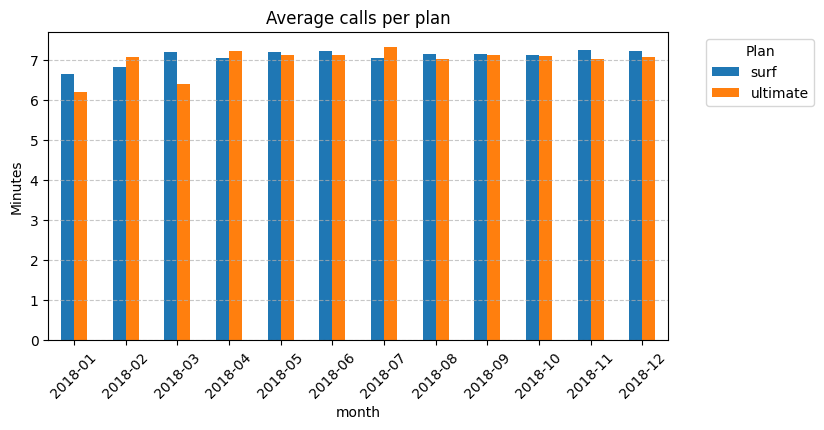

In [148]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

#Calcular el promedio de llamadas por usuario
plan_per_user['avg_per_call']= plan_per_user['minutes_monthly'] /plan_per_user['calls_monthly']
average_calls= plan_per_user.groupby(['plan','month'])['avg_per_call'].mean().unstack()

average_calls.T.plot(kind='bar',figsize=(8,4))
plt.title('Average calls per plan')
plt.ylabel('Minutes')
plt.legend(title= 'Plan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

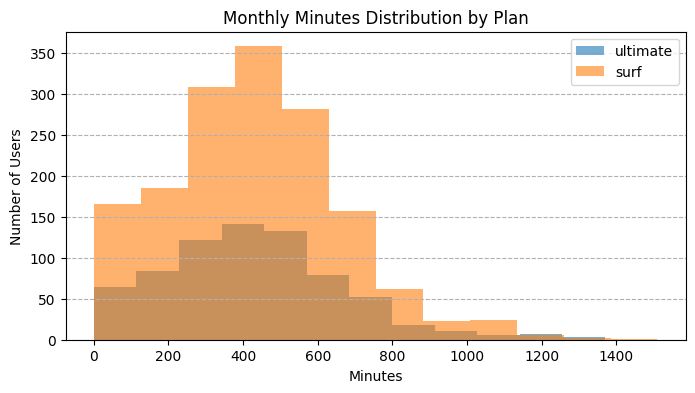

In [149]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

plt.figure(figsize=(8, 4))

for plan in plan_per_user['plan'].unique():
    plt.hist(plan_per_user[ plan_per_user['plan'] == plan]['minutes_monthly'], bins=12, alpha=0.6, label=f'{plan}')

plt.title("Monthly Minutes Distribution by Plan")
plt.xlabel("Minutes")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Correcto, muy bien ambos gráficos. El primero nos muestra que la media de consumos de cada mes son parecidas, mientras que las distribuciones para surf están un poco más concentradas que ultimate.

</div>

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [150]:
# Calcula la media y la varianza de la duración mensual de llamadas.
mean_var_calls_per_plan= plan_per_user.groupby('plan')['minutes_monthly'].agg(['mean', 'var'])
print(mean_var_calls_per_plan)
plan_per_user['minutes_monthly'].describe()

                mean           var
plan                              
surf      428.749523  54968.279461
ultimate  430.450000  57844.464812


count    2293.000000
mean      429.283471
std       236.320077
min         0.000000
25%       265.000000
50%       425.000000
75%       572.000000
max      1510.000000
Name: minutes_monthly, dtype: float64

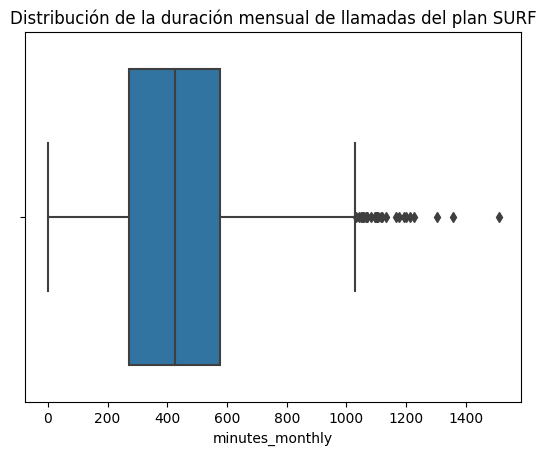

[Text(0.5, 1.0, 'Distribución de la duración mensual de llamadas del plan Ultimate')]

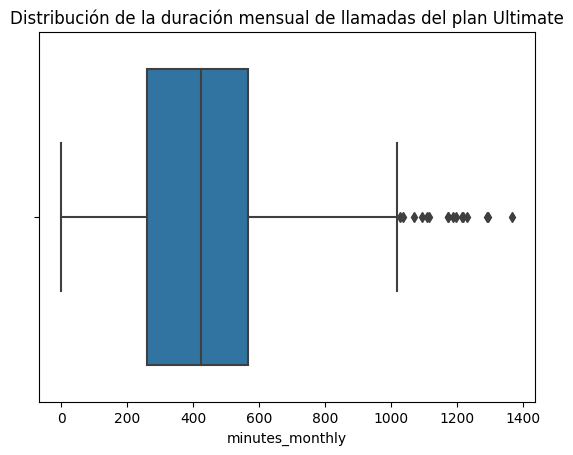

In [151]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

#Dividmos en 2 DFs los usuarios uno por cada plan
surf_users= plan_per_user[plan_per_user['plan']=='surf']
ultimate_users= plan_per_user[plan_per_user['plan']=='ultimate']

#Trazamos un boxplot por cada plan
sns.boxplot(surf_users['minutes_monthly']).set(title='Distribución de la duración mensual de llamadas del plan SURF')
plt.show()
sns.boxplot(ultimate_users['minutes_monthly']).set(title='Distribución de la duración mensual de llamadas del plan Ultimate')

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

Una vez realizadas las limpiezas, transformaciones y operaciones necesarias para el analisis podemos sustentar las siguientes conclusiones de las series CALLS_MONTHLY y MINUTES_MONTHLY (número y duración de llamadas respectivamente):
    
    - Sin existir gran varianza entre meses podemos detectar que el promedio de duración de las llamadas para ambos planes ronda entre los 6 a 7 minutos.
    - El plan SURF se encuentra cercano a los 7 minutos en practicamente todos los meses excepto en enero y febrero donde la tendencia es cercana a 6 minutos. Mientras que en el plan ULTIMATE sufre un fenomeno similar pero solo en enero y marzo, el resto de meses no parece alterar su duración promedio.
    - Observando la gráfica distribución de minutos mensuales así como la el diagrama de caja para ambos planes encontramos que para los dos casos el comportamiento es muy similar aún con la disparidad de número de usuarios.
    - En ambos planes encontramos una media practicamente igual de 407, esta similaridad se repite para la desviación y la varianza.
    - Recordando que el limite de minutos del plan Surf de 500 min vemos que la media está cerca del limite por lo que podemos sostener que al menos un tercio de los usuarios iguala o supera este limite.
    - Por el contrario en el limite para Ultimate de 3000 min donde ninguno de los usuarios llega ni a la mitad de esta cifra.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Buen trabajo, muy bien con las comparaciones. Lo principal a notar es que son parecidos los consumos de ambos planes

</div>

### Mensajes

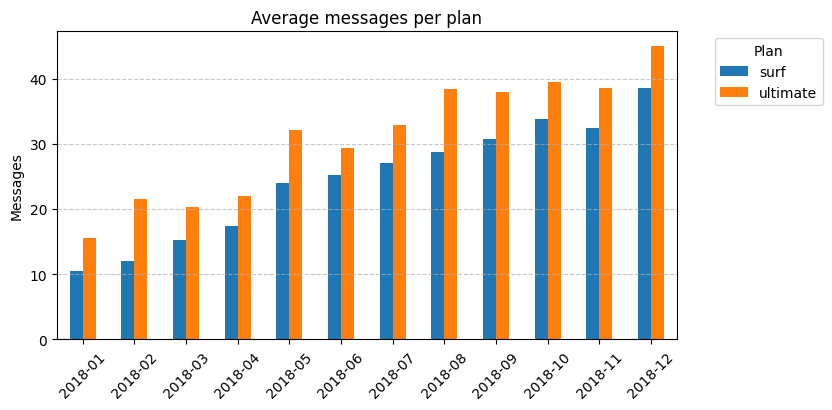

In [152]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
average_messages= plan_per_user.groupby(['plan','month'])['messages_monthly'].mean().unstack()

average_messages.T.plot(kind='bar',figsize=(8,4))
plt.title('Average messages per plan')
plt.ylabel('Messages')
plt.xlabel('')
plt.legend(title= 'Plan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

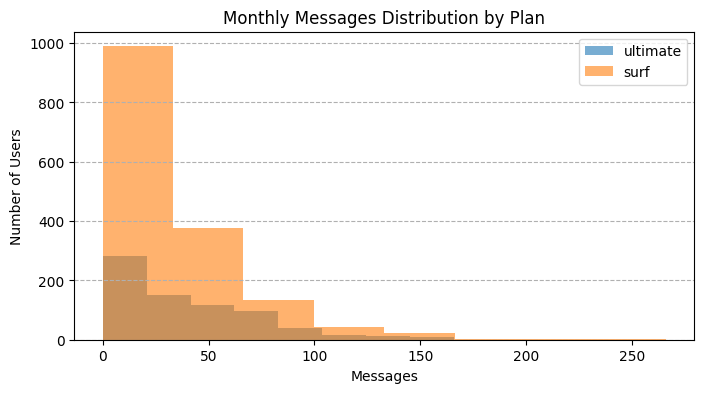

In [153]:
#Compara el número de mensajes mensuales que necesitan los usuarios de cada plan.
plt.figure(figsize=(8, 4))

for plan in plan_per_user['plan'].unique():
    plt.hist(plan_per_user[ plan_per_user['plan'] == plan]['messages_monthly'], bins=8, alpha=0.6, label=f'{plan}')

plt.title("Monthly Messages Distribution by Plan")
plt.xlabel("Messages")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

In [154]:
# Calcula la media y la varianza de los mensajes mensuales.
mean_var_msgs_per_plan= plan_per_user.groupby('plan')['messages_monthly'].agg(['mean', 'var'])
print(mean_var_msgs_per_plan)

plan_per_user['messages_monthly'].describe()

               mean          var
plan                            
surf      31.159568  1126.724522
ultimate  37.551389  1208.756744


count    2293.000000
mean       33.166594
std        34.070085
min         0.000000
25%         3.000000
50%        26.000000
75%        51.000000
max       266.000000
Name: messages_monthly, dtype: float64

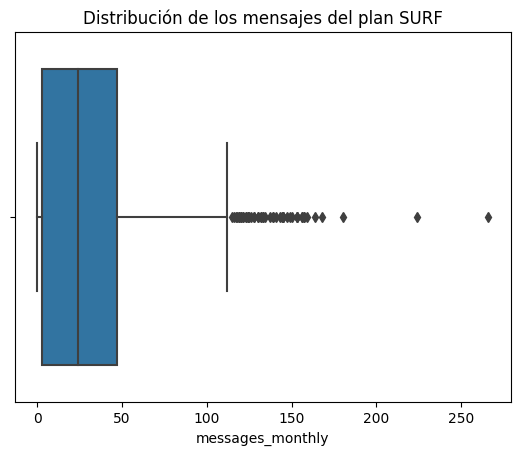

[Text(0.5, 1.0, 'Distribución de los mensajes del plan Ultimate')]

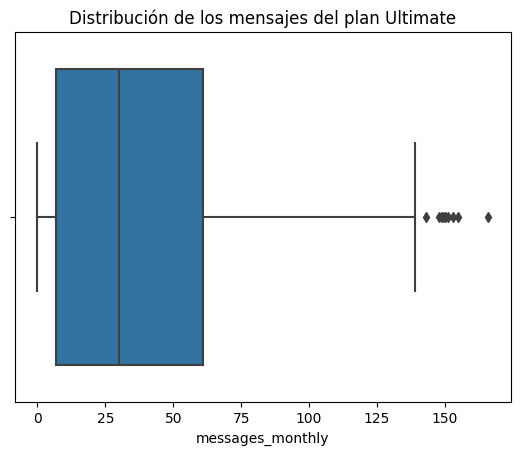

In [155]:
# Traza un diagrama de caja para visualizar la distribución de los mensajes

#Trazamos un boxplot por cada plan
sns.boxplot(surf_users['messages_monthly']).set(title='Distribución de los mensajes del plan SURF')
plt.show()
sns.boxplot(ultimate_users['messages_monthly']).set(title='Distribución de los mensajes del plan Ultimate')

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

Se obtuvieron las siguientes conclusiones de la transformación de la serie MESSAGES_MONTHLY:

    - La tendencia del envío de mensajes para ambos planes crece con respecto al año, en enero el promedio ronda los 11 mensajes para el plan Surf y 15 para el plan Ultimate y crece exponencialmente hasta final de año cerrando con un aproximado de 39 en Surf y 47 Ultimate. Esto representa un aumento de más del triple en ambos casos.
    - La diferencia de envío de mensajes entre planes es abismal, ya que la cantidad de usuarios usando este medio es al menos 4 veces más grande que para Ultimate.
    - El promedio de mensajes de ambos planes es similar siendo de 31 para Surf y 38 para Ultimate. Confirmamos con la gráfica de "Distribución de mensajes por plan" que la gran mayoria de los usuarios de Surf se mantienen por debajo de su limite de 50 mensajes y practicamente todos los usuarios de Ultimate se encuentran por debajo del limite de 100.
    - Sin importar el plan el 75% de los usuarios se alcanza o está por debajo de los 50 mensajes.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Correcto, muy bien el análisis de los mensajes. El último boxplot te sugiero que lo realices por separado para cada plan

</div>

### Internet

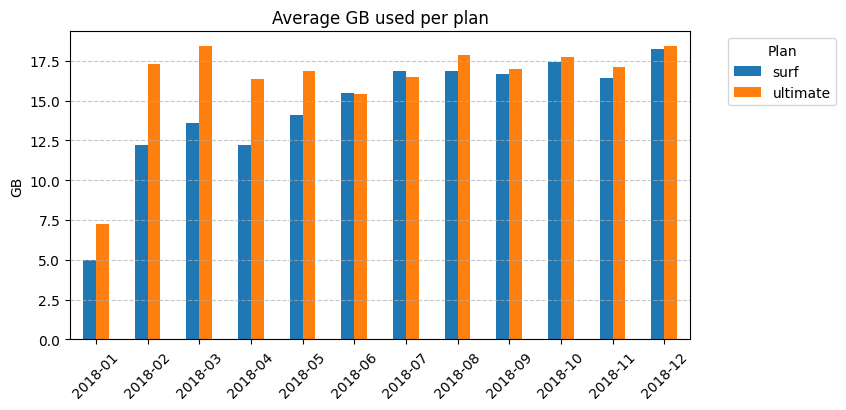

In [156]:
# Comprara el consumo de GB que tienden a usar cada mes los usuarios de cada plan
average_internet= plan_per_user.groupby(['plan','month'])['total_gb_used'].mean().unstack()

average_internet.T.plot(kind='bar',figsize=(8,4))
plt.title('Average GB used per plan')
plt.ylabel('GB')
plt.xlabel('')
plt.legend(title= 'Plan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

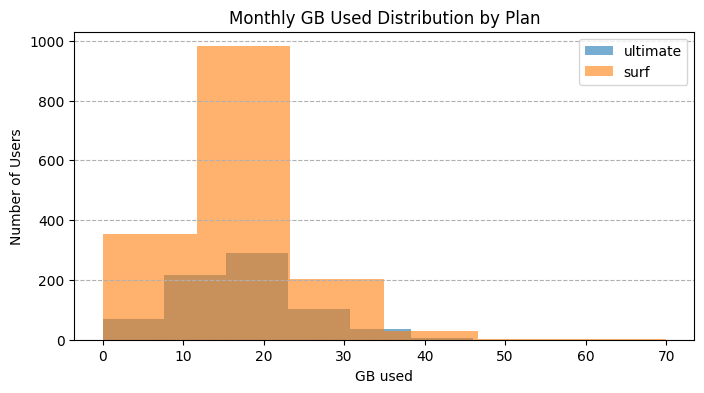

In [157]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
plt.figure(figsize=(8, 4))

for plan in plan_per_user['plan'].unique():
    plt.hist(plan_per_user[ plan_per_user['plan'] == plan]['total_gb_used'], bins=6, alpha=0.6, label=f'{plan}')

plt.title("Monthly GB Used Distribution by Plan")
plt.xlabel("GB used")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

In [158]:
# Calcula la media y la varianza de los GB mensuales.
mean_var_gb_per_plan= plan_per_user.groupby('plan')['total_gb_used'].agg(['mean', 'var'])
print(mean_var_gb_per_plan)

plan_per_user['total_gb_used'].describe()

               mean       var
plan                         
surf      16.670693  61.58360
ultimate  17.306944  58.83055


count    2293.000000
mean       16.870475
std         7.796174
min         0.000000
25%        12.000000
50%        17.000000
75%        21.000000
max        70.000000
Name: total_gb_used, dtype: float64

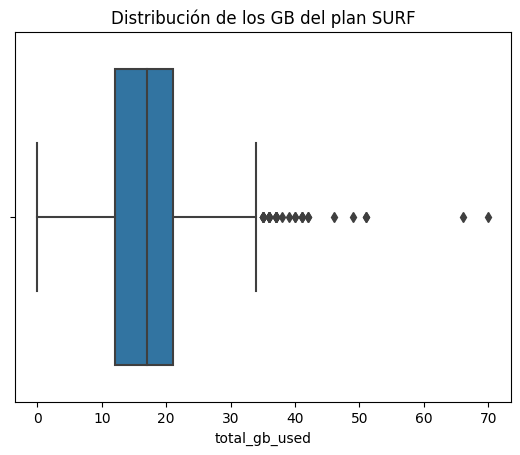

[Text(0.5, 1.0, 'Distribución de los GB del plan Ultimate')]

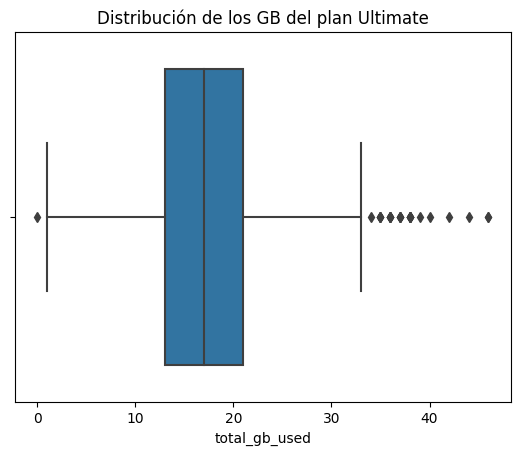

In [159]:
# Traza un diagrama de caja para visualizar la distribución de los GB usados

#Trazamos un boxplot por cada plan
sns.boxplot(surf_users['total_gb_used']).set(title='Distribución de los GB del plan SURF')
plt.show()
sns.boxplot(ultimate_users['total_gb_used']).set(title='Distribución de los GB del plan Ultimate')

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

Continuamos ahora con las conclusiones obtenidas del análisis de la serie TOTAL_GB_USED:

    - Con respecto al uso de GB observamos que para el mes de enero ambos planes se encuentran muy pero debajo del promedio del resto del año. 
    - El plan Surf a partir de febrero crece un promedio 5%, es decir de menos de 12.5 GB hasta más de 17.5 GB. Mientras que el plan Ultimate mantiene una estabilidad que ronda entre los 15 y los 17.5 GB.
    - En el plan Ultimate el mes de marzo se comporta muy similar a diciembre, este fenomeno es bastante curioso y hasta ahora solo ha sucedido con el internet y no en el resto de servicios.
     - Nuevamente los promedios de uso son bastante similares, siendo 16 GB para Surf y 17 GB para Ultimate. Para ambos planes 3/4 del total de usuarios se mantienen dentro del limite de un consumo de 21 GB.
     - Recordando el limite del plan Surf de internet es de 15 GB por lo que al saber de este promedio de 16 GB sabemos que más de la mitad de los usarios de este plan generan recargos por el uso extra de GB. Por el contrario del limite de Ultimate que es de 30GB y deducimos que menos de un 10% de los usuarios sobrepasa este limite.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Correcto, muy bien el análisis de los mensajes. El último boxplot te sugiero que lo realices por separado para cada plan

</div>

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor</b> <a class="tocSkip"></a>

Para esta parte se requiere el cálculo del ingreso corregido.

</div>

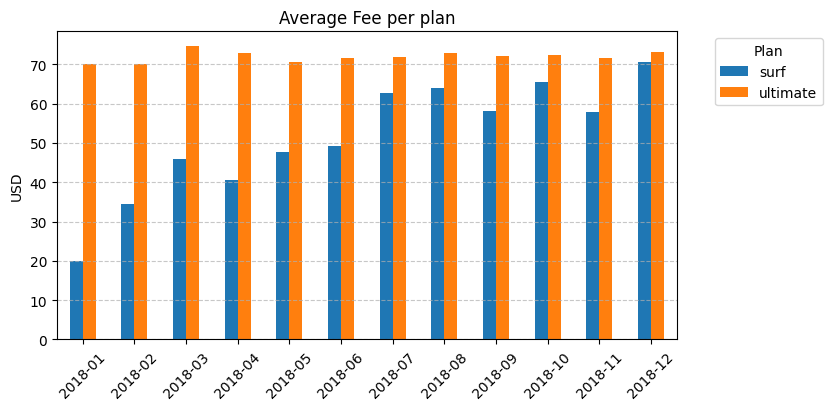

In [160]:
# Comprara las tarifas que tienden a pagar cada mes los usuarios de cada plan
average_fee= plan_per_user.groupby(['plan','month'])['fee_plus_extra'].mean().unstack()

average_fee.T.plot(kind='bar',figsize=(8,4))
plt.title('Average Fee per plan')
plt.ylabel('USD')
plt.xlabel('')
plt.legend(title= 'Plan', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

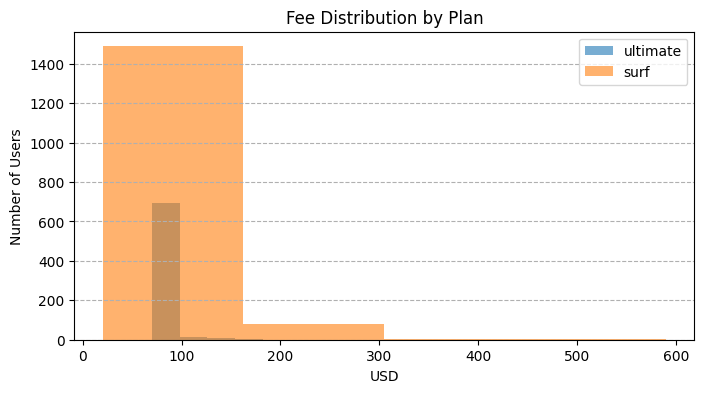

In [161]:
# Compara las tarifas por usuarios por plan
plt.figure(figsize=(8, 4))

for plan in plan_per_user['plan'].unique():
    plt.hist(plan_per_user[ plan_per_user['plan'] == plan]['fee_plus_extra'], bins=4, alpha=0.6, label=f'{plan}')

plt.title("Fee Distribution by Plan")
plt.xlabel("USD")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Muy bien con los gráficos. Aquí ya se nota la poca variabilidad de ultimate.

</div>

In [162]:
# Calcula la media y la varianza de las tarifas mensuales por plan.
mean_var_fee_plan= plan_per_user.groupby('plan')['fee_plus_extra'].agg(['mean', 'var'])
print(mean_var_fee_plan)

plan_per_user['fee_plus_extra'].describe()

               mean          var
plan                            
surf      60.706408  3067.835152
ultimate  72.313889   129.848486


count    2293.000000
mean       64.351147
std        46.624945
min        20.000000
25%        23.480000
50%        70.000000
75%        70.000000
max       590.370000
Name: fee_plus_extra, dtype: float64

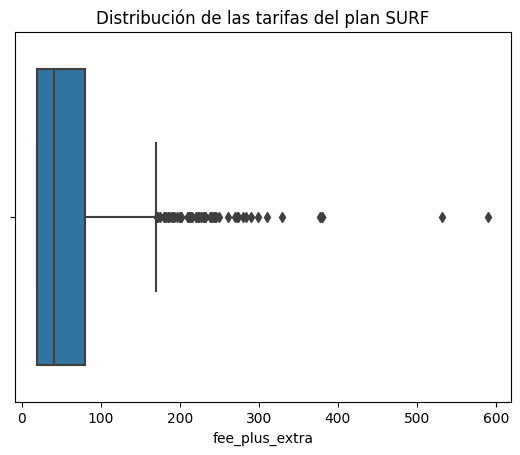

[Text(0.5, 1.0, 'Distribución de las tarifas del plan Ultimate')]

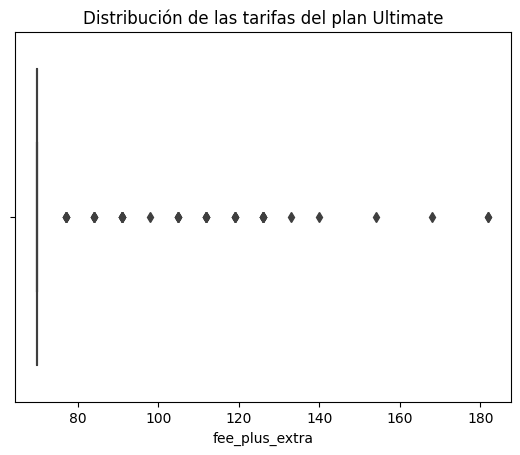

In [163]:
# Traza un diagrama de caja para visualizar la distribución de las tarifas

#Trazamos un boxplot por cada plan
sns.boxplot(surf_users['fee_plus_extra']).set(title='Distribución de las tarifas del plan SURF')
plt.show()
sns.boxplot(ultimate_users['fee_plus_extra']).set(title='Distribución de las tarifas del plan Ultimate')

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

Por ultimo realizaremos las conlusiones sobre la serie FEE_PER_PLAN el cual incluye el valor de la tarifa base más los costos extras generados por los usuarios:

    - Observamos que a lo largo de todo el año el comportamiento de la tarifa mensual del plan Ultimate se mantiene practicamente similiar y cercana al valor base de la tarifa de 70 USD. Mientras que en caso contrario es el plan Surf que solo en enero es el valor base de 20 USD y a partir de ahi se incremente un promedio de 30% por trimestre y termina en diciembre casi igualando el costo del plan Ultimate; esto es lógico considerando que alrededor del 50% de los ususarios del plan Surf sobrepasan los limites en llamadas, mensajes e internet.
    - Prestando atención en el diagrama de la "distribucion de tarifas de usuarios por plan" y al calculo de promedios es mas que evidente que para el plan Surf el promedio ronda los 60 USD y mucho menos del 25% de sus usuarios pagan solo la tarifa base. En contraste con el plan Ultimate que el promedio es 72 USD que es bastante cercano al valor base de la tarifa.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Correcto!

</div>

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [164]:
# Prueba las hipótesis
#H0 - Son IGUALES los ingresos promedio
#H1 - Son DIFERENTES los ingresos promedio

#alpha value
alpha=0.05

#Comprobación de hipótesis
first_hipotesis= st.ttest_ind(surf_users['extra_cost_per_call'], ultimate_users['extra_cost_per_call'])

print('valor p: ', first_hipotesis.pvalue) # extraer el valor p

if first_hipotesis.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  4.6748051494569595e-38
Rechazamos la hipótesis nula


<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Muy bien, correcto el test

</div>

[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [165]:
# Prueba las hipótesis
#H0 - El ingreso promedio de los usuarios del área NY-NJ es IGUAL a otras regiones
#H1 - El ingreso promedio de los usuarios del área NY-NJ es DIFERENTE a otras regiones

#Generamos un DF solo con los usuarios del área NY-NJ y otro DF contrario al primero
ny_users= plan_per_user[plan_per_user['city'].str.contains('NY-NJ', case=False, na=False)]['fee_plus_extra']
not_ny_users= plan_per_user[~plan_per_user['city'].str.contains('NY-NJ', case=False, na=False)]['fee_plus_extra']

#alpha value
alpha=0.05

#Comprobación de hipótesis
second_hipotesis= st.ttest_ind(ny_users, not_ny_users)

print('valor p: ', second_hipotesis.pvalue) # extraer el valor p

if second_hipotesis.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  0.043557431621342436
Rechazamos la hipótesis nula


<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Bien hecho, la data y el test son correctos. En futuros t-test puedes utilizar el test de levene antes para determinar si se usan varianzas iguales o diferentes.

</div>

## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

Una vez finalizado el proyecto me gustaría plasmar las siguientes anotaciones sobre el proceso:

    - Desde un inicio los DF generados fueron utilizados practicamente sin transformaciones ni modificaciones substanciales.
    - Suponemos que tanto los usuarios activos como los inactivos son importantes y válidos para su analisis y posterior experimentación en las hipótesis.



De igual forma se obtuvieron las siguientes conclusiones finales.

    - Podemos observar que el comportamiento general de ambos planes son muy similares, los usuarios del plan Surf tienden a superar constatemente los limites de los servicios de llamadas, mensajes e internet y estos costos extras acercan los ingresos de estos usuarios a practicamente el mismo valor de la tarifa base del plan Ultimate.
    - Por otro lado los usuarios de Ultimate son bastante constantes con el uso de servicios de llamadas e internet obtiendo un promedio de estos sin mucha variedad entre meses. Estos usuarios rara vez incurren en costos extras y su promedio de ingresos es practicamente igual al valor de su tarifa base.
    - La primera hipótesis demostró que el ingreso por costos extras de llamadas es amplia entre planes y tiene sentido ya que como se mostró en diferentes gráficos a lo largo de la sección de "1.13 Estudia el comportamiento de las tarifas", el plan Surf incurre constantemente en costos extras por superar el limite de su plan a difrencia de los usuarios del plan Ultimate.
    - Es importante recalcar el resultado de la segunda hipótesis en el cual se comprueba que el área de NY-NJ se comporta practicamente igual al resto de las áreas, esto solo refuerza el concepto del comportamiento similar de servicicios de los usuarios sin mucha variedad entre planes.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor v2</b> <a class="tocSkip"></a>

Muy bien con las conclusiones, pero te recomiendo incluir algunas métricas en las afirmaciones que realizas, le darían más fuerza.

</div>